# Structural Break Diagnostics

Pre-estimation workflow for checking stationarity and structural breaks in time series data, to inform sample selection before fitting structural models (HLW, ARIMA, VAR, etc.).

**Workflow:**
1. Load data, eyeball it (level, rolling stats, rolling correlation)
2. Stationarity check (ADF, KPSS)
3. Break tests on univariate series (Quandt-Andrews, CUSUM)
4. Break tests on bivariate relationship (Quandt-Andrews on regression)
5. Multiple-break detection (`ruptures`)
6. Manual sample-selection decision based on evidence

**Design principle:** the notebook surfaces evidence; *you* decide where to split the sample. Don't automate the decision.

## 0. Setup

In [1]:

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from statsmodels.tsa.stattools import adfuller, kpss
from statsmodels.regression.linear_model import OLS
from statsmodels.tools.tools import add_constant
from statsmodels.stats.diagnostic import breaks_cusumolsresid

import ruptures as rpt

import warnings
warnings.filterwarnings('ignore')

sns.set_style('whitegrid')
plt.rcParams['figure.figsize'] = (12, 5)
plt.rcParams['figure.dpi'] = 100

## 1. Load data

Edit this cell for your data. The notebook expects:
- `y`: the primary series of interest (e.g., output gap) as a pandas Series with DatetimeIndex
- `x`: optional second series for relationship testing (e.g., real rate). Set to `None` for univariate-only.
- `freq`: 'Q' for quarterly, 'M' for monthly, 'A' for annual. Affects window sizes.

Example placeholder data is generated below. Replace it with your actual load.

In [19]:
# ---- REPLACE THIS BLOCK WITH YOUR DATA LOAD ----
# Read input data from FRBNY website
raw_data =  pd.read_excel("C:\\Documents\\CEPAL\\Tasa-Natural-de-Interes\\HLW_2023_Replication_Code\\HLW_2023_Replication_Code\\inputData\\Holston_Laubach_Williams_MEX.xlsx", sheet_name="MEX Input Data")
raw_data = raw_data.set_index("Date")

y_data = raw_data['output.gap'].values
y = pd.Series(y_data, index=raw_data.index, name='output_gap')

# Rate-like series correlated with y but with shifting relationship
x_data = raw_data['real.rate'].values
x = pd.Series(x_data, index=raw_data.index, name='real_rate')

freq = 'Q'
# ---- END DATA LOAD BLOCK ----

# Combine into a DataFrame for convenience
df = pd.concat([y, x], axis=1) if x is not None else y.to_frame()

# Window size for rolling stats: ~5 years
window = {'Q': 20, 'M': 60, 'A': 5}[freq]

print(f'Series: {y.name}' + (f' and {x.name}' if x is not None else ''))
print(f'Frequency: {freq}, n = {len(df)}')
print(f'Range: {df.index.min().date()} to {df.index.max().date()}')
print(f'Rolling window: {window} periods')
df.head()

Series: output_gap and real_rate
Frequency: Q, n = 69
Range: 2006-01-01 to 2023-01-01
Rolling window: 20 periods


,output_gap,real_rate
Date,,
2006-01-01,0.002649,4.431581
2006-04-01,0.008201,3.376993
2006-07-01,0.006794,3.775138
2006-10-01,0.005133,3.136594
2007-01-01,0.008012,2.276386


## 2. Eyeball the data

Look first. Note any obvious regime changes, outliers, or shifts before any test tells you what to think.

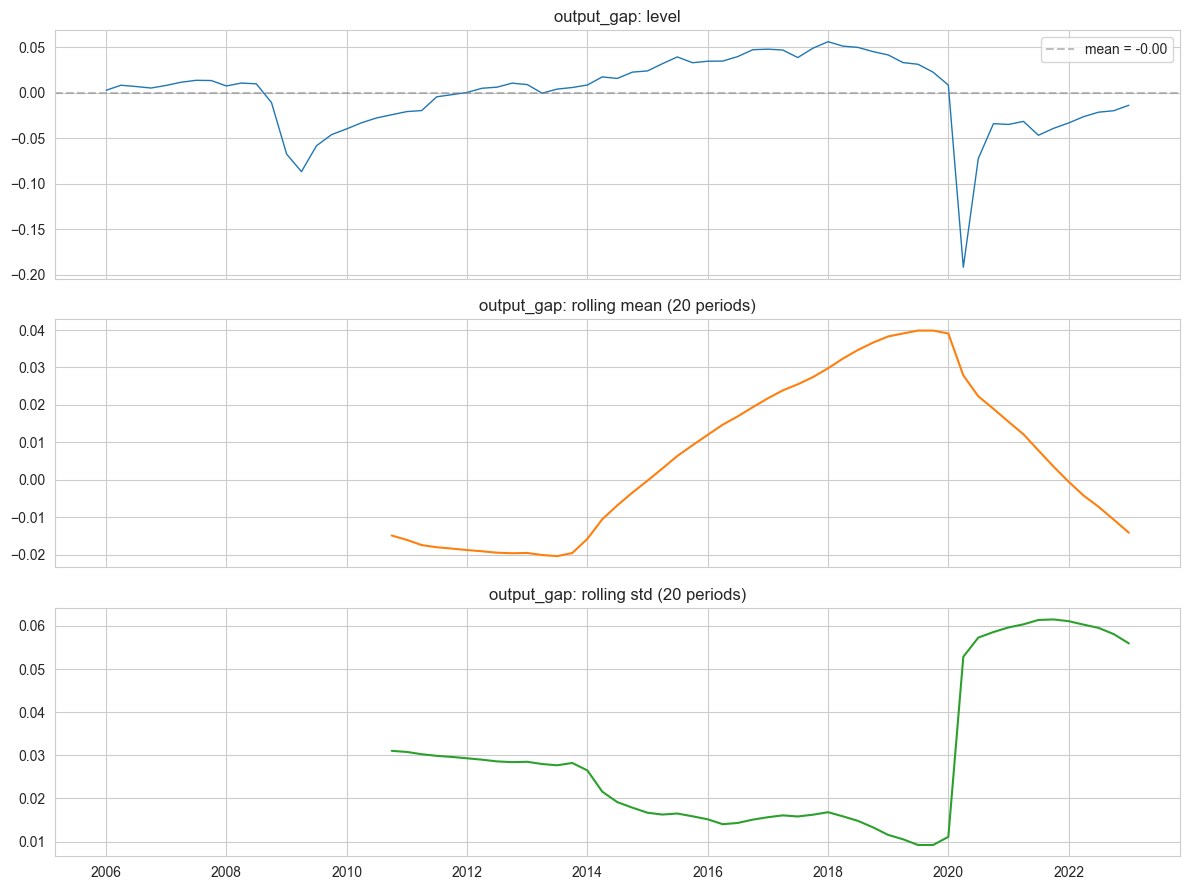

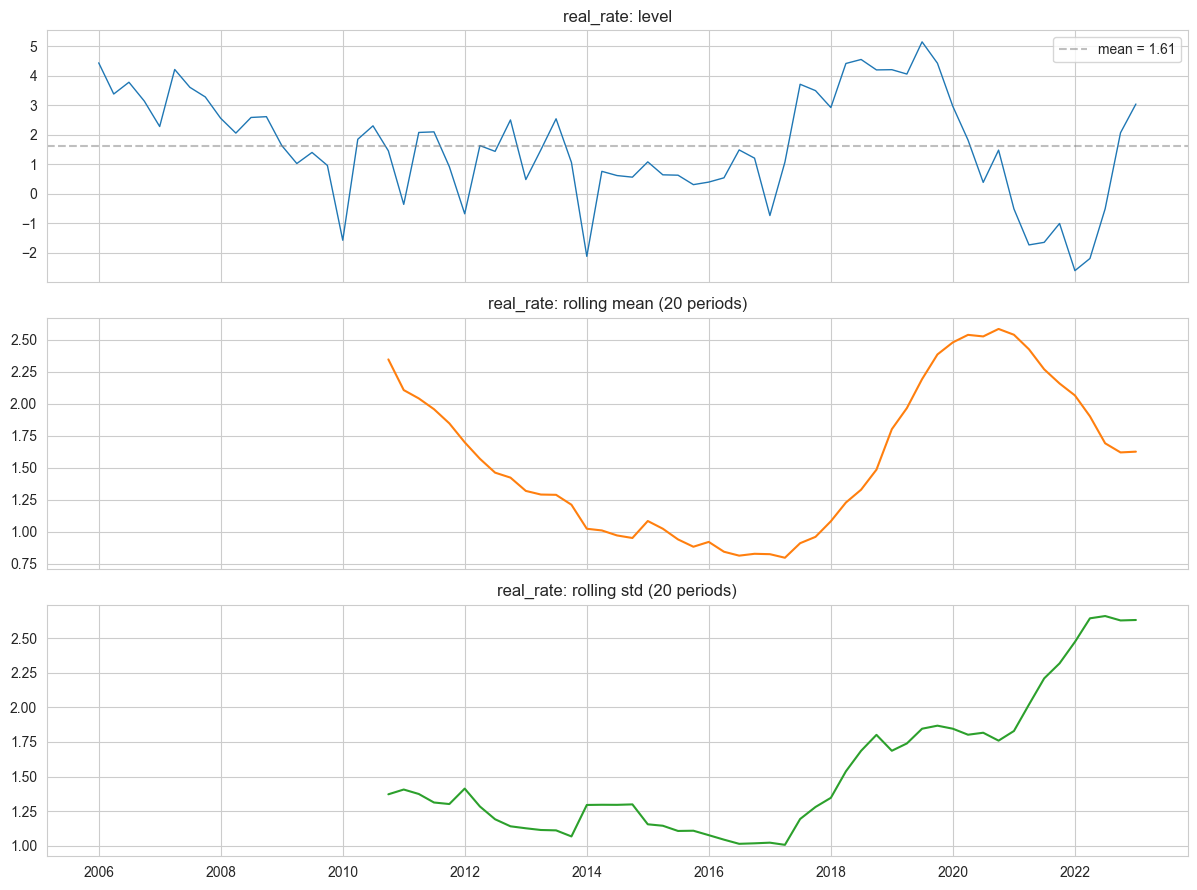

In [ ]:
def eyeball_univariate(s: pd.Series, window: int):
    """Plot level, rolling mean, rolling std for a single series."""
    fig, axes = plt.subplots(3, 1, figsize=(12, 9), sharex=True)

    axes[0].plot(s.index, s.values, lw=1)
    axes[0].axhline(s.mean(), color='gray', ls='--', alpha=0.5, label=f'mean = {s.mean():.2f}')
    axes[0].set_title(f'{s.name}: level')
    axes[0].legend()

    axes[1].plot(s.index, s.rolling(window).mean(), lw=1.5, color='C1')
    axes[1].set_title(f'{s.name}: rolling mean ({window} periods)')

    axes[2].plot(s.index, s.rolling(window).std(), lw=1.5, color='C2')
    axes[2].set_title(f'{s.name}: rolling std ({window} periods)')

    plt.tight_layout()
    plt.show()

eyeball_univariate(y, window)
if x is not None:
    eyeball_univariate(x, window)

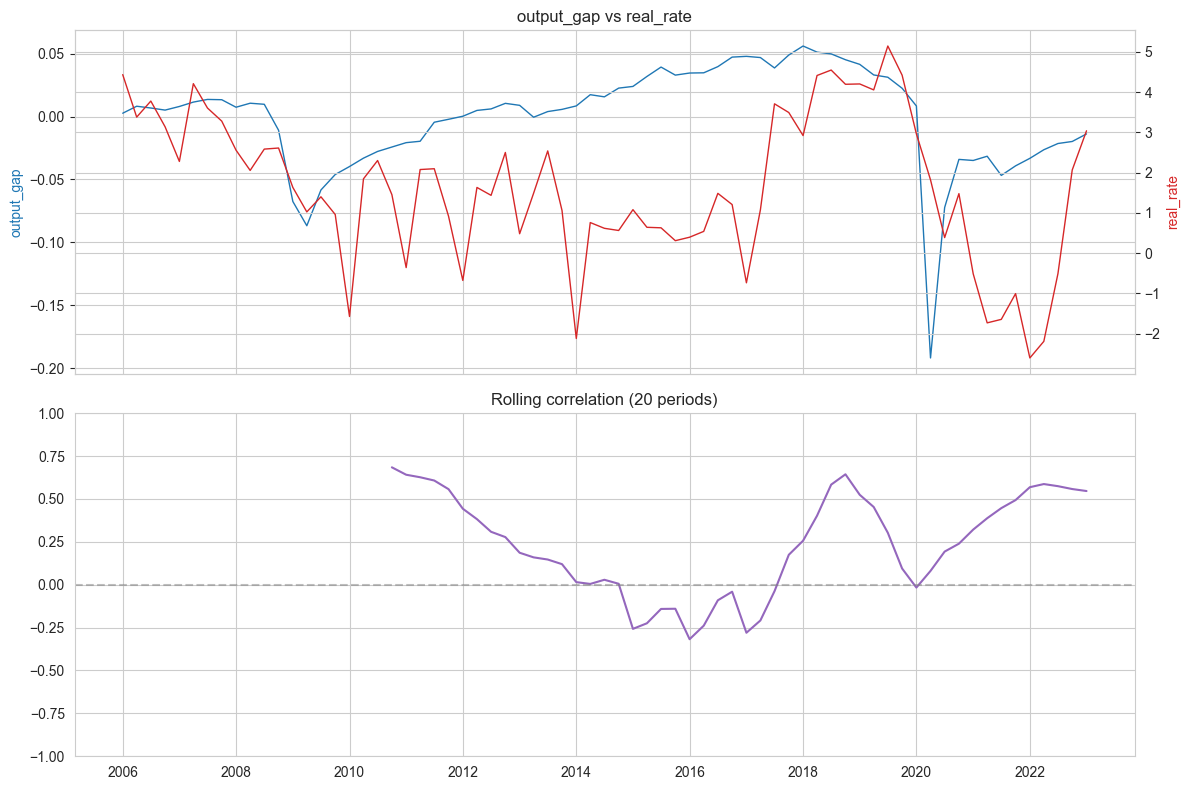

Full-sample correlation: 0.334


In [30]:
def eyeball_bivariate(y: pd.Series, x: pd.Series, window: int):
    """Plot two series on twin axes + rolling correlation."""
    fig, axes = plt.subplots(2, 1, figsize=(12, 8), sharex=True)

    ax1 = axes[0]
    ax2 = ax1.twinx()
    ax1.plot(y.index, y.values, color='C0', lw=1, label=y.name)
    ax2.plot(x.index, x.values, color='C3', lw=1, label=x.name)
    ax1.set_ylabel(y.name, color='C0')
    ax2.set_ylabel(x.name, color='C3')
    ax1.set_title(f'{y.name} vs {x.name}')

    rolling_corr = y.rolling(window).corr(x)
    axes[1].plot(rolling_corr.index, rolling_corr.values, lw=1.5, color='C4')
    axes[1].axhline(0, color='gray', ls='--', alpha=0.5)
    axes[1].set_title(f'Rolling correlation ({window} periods)')
    axes[1].set_ylim(-1, 1)

    plt.tight_layout()
    plt.show()

    print(f'Full-sample correlation: {y.corr(x):.3f}')

if x is not None:
    eyeball_bivariate(y, x, window)

### What to look for

- **Level shifts**: rolling mean jumps to a new level and stays there → likely a break in the mean.
- **Variance shifts**: rolling std changes regime → likely a break in volatility.
- **Rolling correlation swings**: if `corr(y, x)` is +0.6 in one period and -0.2 in another, the *relationship* between them is unstable. This is the most important diagnostic for structural models like HLW that assume constant coefficients.
- **Trend changes**: persistent slope changes in the level plot → trend breaks, separate from level breaks.

## 3. Stationarity check

Most break tests assume stationarity (or known order of integration). Run before tests.

**Reading the output:**
- ADF: null hypothesis is *unit root* (non-stationary). p < 0.05 → reject unit root → series is stationary.
- KPSS: null hypothesis is *stationarity*. p < 0.05 → reject stationarity → unit root.
- They should *agree*. If they disagree, the series is ambiguous — likely a near-unit-root or has a structural break that's confusing the tests.

In [31]:
def stationarity_tests(s: pd.Series):
    """Run ADF and KPSS, print interpretation."""
    s_clean = s.dropna()

    adf_stat, adf_p, _, _, adf_crit, _ = adfuller(s_clean, autolag='AIC')
    kpss_stat, kpss_p, _, kpss_crit = kpss(s_clean, regression='c', nlags='auto')

    print(f'--- {s.name} ---')
    print(f'ADF:  stat = {adf_stat:.3f}, p = {adf_p:.4f}')
    print(f'      {"stationary" if adf_p < 0.05 else "unit root (non-stationary)"} at 5%')
    print(f'KPSS: stat = {kpss_stat:.3f}, p = {kpss_p:.4f}')
    print(f'      {"unit root" if kpss_p < 0.05 else "stationary"} at 5%')

    adf_says_stat = adf_p < 0.05
    kpss_says_stat = kpss_p >= 0.05
    if adf_says_stat and kpss_says_stat:
        verdict = 'STATIONARY (both agree)'
    elif (not adf_says_stat) and (not kpss_says_stat):
        verdict = 'NON-STATIONARY (both agree) — consider differencing'
    else:
        verdict = 'AMBIGUOUS (tests disagree) — possibly near-unit-root or structural break'
    print(f'Verdict: {verdict}\n')

stationarity_tests(y)
if x is not None:
    stationarity_tests(x)

--- output_gap ---
ADF:  stat = -3.303, p = 0.0147
      stationary at 5%
KPSS: stat = 0.177, p = 0.1000
      stationary at 5%
Verdict: STATIONARY (both agree)

--- real_rate ---
ADF:  stat = -2.539, p = 0.1062
      unit root (non-stationary) at 5%
KPSS: stat = 0.176, p = 0.1000
      stationary at 5%
Verdict: AMBIGUOUS (tests disagree) — possibly near-unit-root or structural break



## 4. Univariate break tests

Test whether the mean of the series shifts at an unknown date.

**Quandt-Andrews (sup-F)**: tests for a break at any date in the middle 70% of the sample. Returns the most likely break date and a p-value.

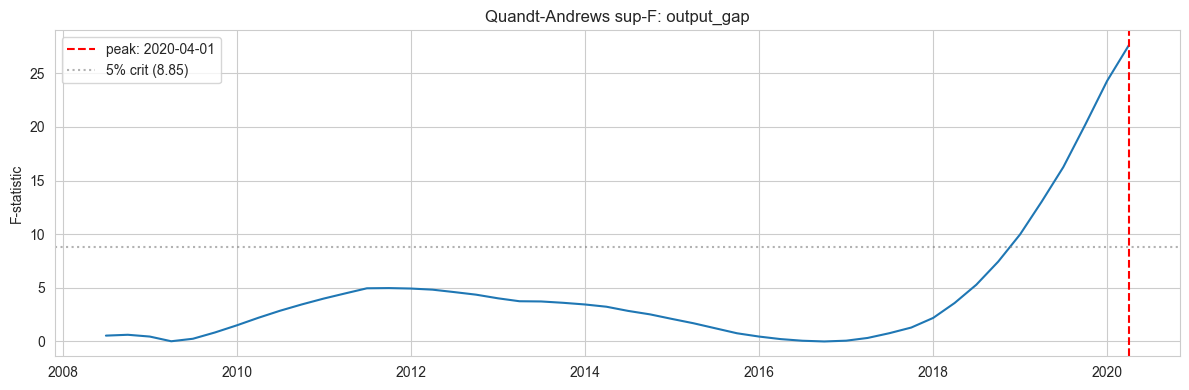

sup-F = 27.61 at 2020-04-01 [***]
  (* = 10%, ** = 5%, *** = 1%, n.s. = not significant)



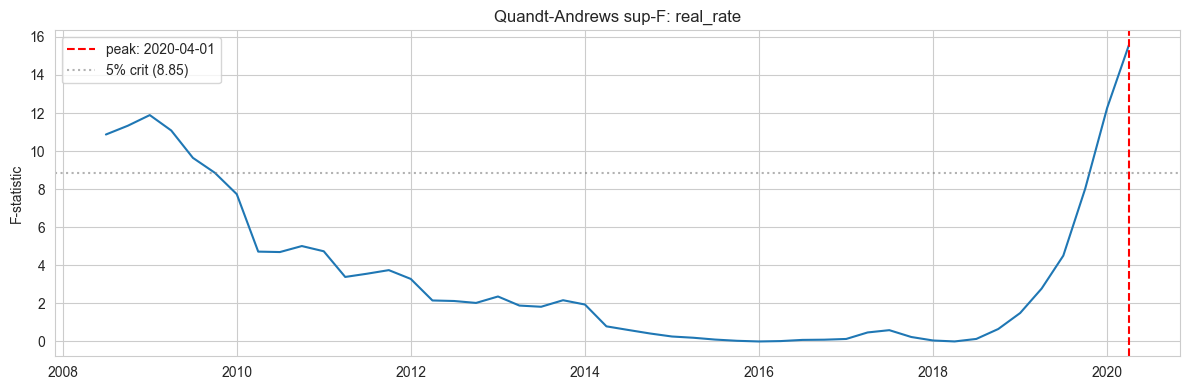

sup-F = 15.56 at 2020-04-01 [***]
  (* = 10%, ** = 5%, *** = 1%, n.s. = not significant)



In [32]:
def quandt_andrews_univariate(s: pd.Series, trim: float = 0.15):
    """
    Sup-F test for break in mean at unknown date.
    Searches middle (1 - 2*trim) of the sample.
    """
    s_clean = s.dropna()
    n = len(s_clean)
    start = int(n * trim)
    end = int(n * (1 - trim))

    f_stats = []
    for t in range(start, end):
        pre = s_clean.iloc[:t].values
        post = s_clean.iloc[t:].values
        # F-test for difference in means (assuming equal var; could refine)
        var_p = ((pre.var(ddof=1) * (len(pre)-1) + post.var(ddof=1) * (len(post)-1))
                 / (n - 2))
        if var_p <= 0:
            f_stats.append(0)
            continue
        t_stat = (pre.mean() - post.mean()) / np.sqrt(var_p * (1/len(pre) + 1/len(post)))
        f_stats.append(t_stat**2)

    f_stats = np.array(f_stats)
    sup_f = f_stats.max()
    best_idx = f_stats.argmax() + start
    best_date = s_clean.index[best_idx]

    # Andrews (1993) approximate critical values for sup-F with 1 parameter, trim=0.15:
    # 10%: 7.17, 5%: 8.85, 1%: 12.35
    sig = '***' if sup_f > 12.35 else '**' if sup_f > 8.85 else '*' if sup_f > 7.17 else 'n.s.'

    fig, ax = plt.subplots(figsize=(12, 4))
    dates_searched = s_clean.index[start:end]
    ax.plot(dates_searched, f_stats, lw=1.5)
    ax.axvline(best_date, color='red', ls='--', label=f'peak: {best_date.date()}')
    ax.axhline(8.85, color='gray', ls=':', alpha=0.6, label='5% crit (8.85)')
    ax.set_title(f'Quandt-Andrews sup-F: {s.name}')
    ax.set_ylabel('F-statistic')
    ax.legend()
    plt.tight_layout()
    plt.show()

    print(f'sup-F = {sup_f:.2f} at {best_date.date()} [{sig}]')
    print(f'  (* = 10%, ** = 5%, *** = 1%, n.s. = not significant)\n')
    return best_date, sup_f

qa_y_date, qa_y_stat = quandt_andrews_univariate(y)
if x is not None:
    qa_x_date, qa_x_stat = quandt_andrews_univariate(x)

## 5. Bivariate break test (the important one for HLW-style models)

Test whether the *coefficient* relating x to y has shifted. Different from univariate breaks: each series might be stable on its own, but the relationship between them might have changed.

Runs a Chow test at every candidate break date and finds the maximum F-statistic (Quandt-Andrews for regression coefficients).

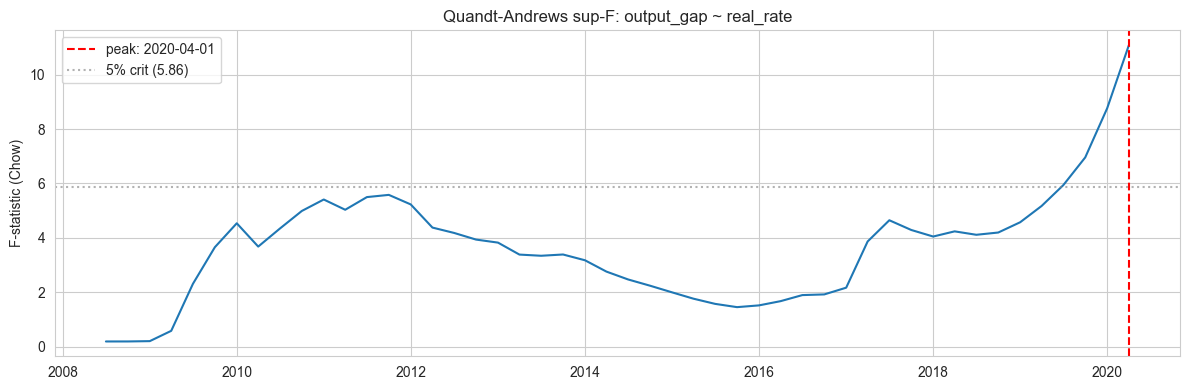

sup-F = 11.09 at 2020-04-01 [***]
  Pre-break  (2006-01-01 to 2020-04-01):
    alpha = 0.000, beta = 0.005, n = 57
  Post-break (2020-04-01 to 2023-01-01):
    alpha = -0.048, beta = -0.006, n = 12



In [33]:
def quandt_andrews_regression(y: pd.Series, x: pd.Series, trim: float = 0.15):
    """
    Sup-F test for break in regression coefficients of y on x at unknown date.
    Regression: y_t = alpha + beta * x_t + e_t
    Tests whether (alpha, beta) shift at any date in the middle.
    """
    data = pd.concat([y, x], axis=1).dropna()
    n = len(data)
    start = int(n * trim)
    end = int(n * (1 - trim))

    y_arr = data.iloc[:, 0].values
    X_arr = add_constant(data.iloc[:, 1].values)

    # Full-sample RSS
    full_res = OLS(y_arr, X_arr).fit()
    rss_full = (full_res.resid**2).sum()
    k = X_arr.shape[1]  # 2

    f_stats = []
    for t in range(start, end):
        try:
            res_pre = OLS(y_arr[:t], X_arr[:t]).fit()
            res_post = OLS(y_arr[t:], X_arr[t:]).fit()
            rss_split = (res_pre.resid**2).sum() + (res_post.resid**2).sum()
            # Chow F-statistic
            f = ((rss_full - rss_split) / k) / (rss_split / (n - 2*k))
            f_stats.append(f)
        except Exception:
            f_stats.append(0)

    f_stats = np.array(f_stats)
    sup_f = f_stats.max()
    best_idx = f_stats.argmax() + start
    best_date = data.index[best_idx]

    # Andrews (1993) critical values for sup-F with 2 parameters, trim=0.15:
    # 10%: 5.00, 5%: 5.86, 1%: 7.78
    sig = '***' if sup_f > 7.78 else '**' if sup_f > 5.86 else '*' if sup_f > 5.00 else 'n.s.'

    fig, ax = plt.subplots(figsize=(12, 4))
    dates_searched = data.index[start:end]
    ax.plot(dates_searched, f_stats, lw=1.5)
    ax.axvline(best_date, color='red', ls='--', label=f'peak: {best_date.date()}')
    ax.axhline(5.86, color='gray', ls=':', alpha=0.6, label='5% crit (5.86)')
    ax.set_title(f'Quandt-Andrews sup-F: {y.name} ~ {x.name}')
    ax.set_ylabel('F-statistic (Chow)')
    ax.legend()
    plt.tight_layout()
    plt.show()

    print(f'sup-F = {sup_f:.2f} at {best_date.date()} [{sig}]')
    print(f'  Pre-break  ({data.index[0].date()} to {best_date.date()}):')
    pre_res = OLS(y_arr[:best_idx], X_arr[:best_idx]).fit()
    print(f'    alpha = {pre_res.params[0]:.3f}, beta = {pre_res.params[1]:.3f}, n = {best_idx}')
    print(f'  Post-break ({best_date.date()} to {data.index[-1].date()}):')
    post_res = OLS(y_arr[best_idx:], X_arr[best_idx:]).fit()
    print(f'    alpha = {post_res.params[0]:.3f}, beta = {post_res.params[1]:.3f}, n = {n - best_idx}')
    print()
    return best_date, sup_f

if x is not None:
    qa_reg_date, qa_reg_stat = quandt_andrews_regression(y, x)

## 6. Multiple-break detection with `ruptures`

Quandt-Andrews finds the *single* most likely break. If you suspect multiple breaks (e.g., 2008 GFC *and* 2020 COVID), use a method that handles that.

`ruptures` uses penalized cost minimization (similar idea to Bai-Perron). Set `pen` higher → fewer breaks detected; lower → more breaks. Worth trying a few values.

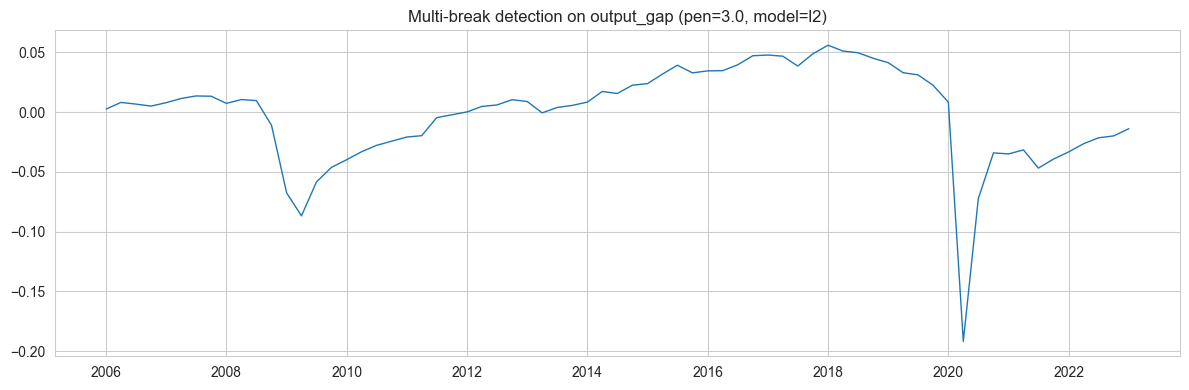

Detected 0 break(s):



In [34]:
def multi_break_detection(s: pd.Series, pen: float = 3.0, model: str = 'l2'):
    """
    Detect multiple breaks using ruptures (PELT algorithm).

    model='l2' detects changes in mean.
    model='rbf' is more general (mean and variance).
    Higher pen = fewer breaks.
    """
    s_clean = s.dropna()
    signal = s_clean.values.reshape(-1, 1)

    algo = rpt.Pelt(model=model).fit(signal)
    break_idx = algo.predict(pen=pen)
    # ruptures includes the endpoint in the result; drop it for interpretation
    break_idx = [b for b in break_idx if b < len(signal)]
    break_dates = [s_clean.index[i] for i in break_idx]

    fig, ax = plt.subplots(figsize=(12, 4))
    ax.plot(s_clean.index, s_clean.values, lw=1)
    for d in break_dates:
        ax.axvline(d, color='red', ls='--', alpha=0.7)
    ax.set_title(f'Multi-break detection on {s.name} (pen={pen}, model={model})')
    plt.tight_layout()
    plt.show()

    print(f'Detected {len(break_dates)} break(s):')
    for d in break_dates:
        print(f'  {d.date()}')
    print()
    return break_dates

# Run with default penalty; try pen=1, 3, 10 and compare
_ = multi_break_detection(y, pen=3.0, model='l2')

=== penalty = 1.0 ===


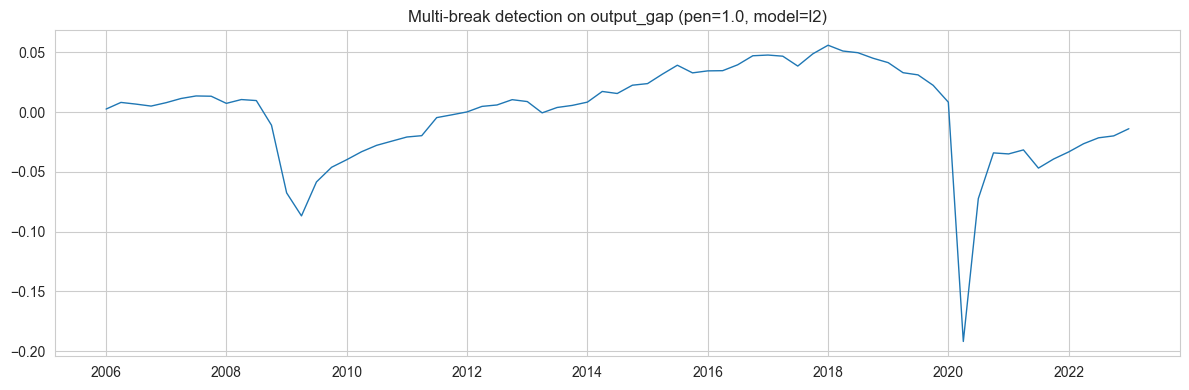

Detected 0 break(s):

=== penalty = 3.0 ===


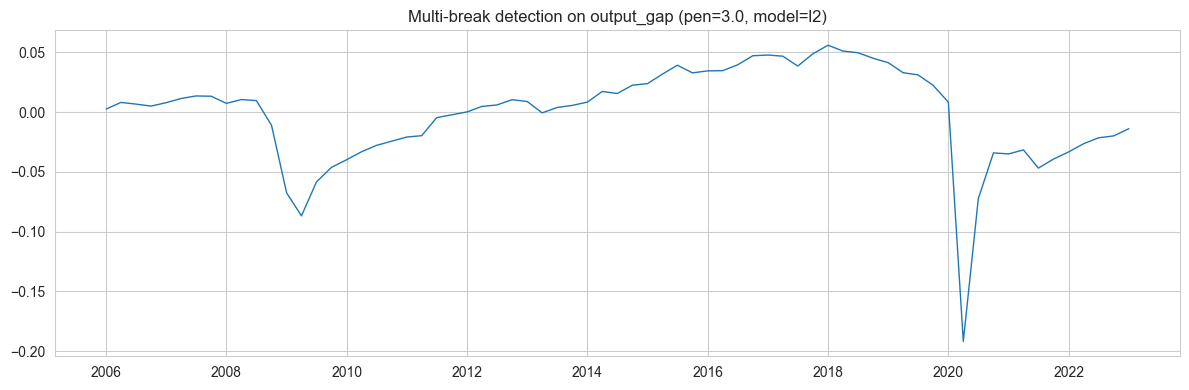

Detected 0 break(s):

=== penalty = 10.0 ===


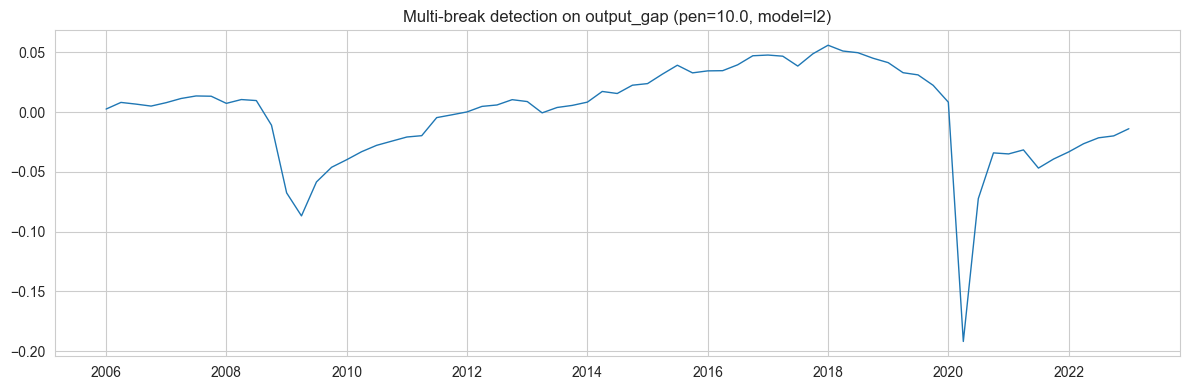

Detected 0 break(s):



In [35]:
# Try a couple penalty values to see sensitivity
for p in [1.0, 3.0, 10.0]:
    print(f'=== penalty = {p} ===')
    _ = multi_break_detection(y, pen=p, model='l2')

## 7. CUSUM (visual robustness check)

CUSUM plots a cumulative sum of recursive residuals. If it drifts outside the 5% bands, parameters are unstable somewhere. Useful for catching gradual breaks that sharp-break tests miss.

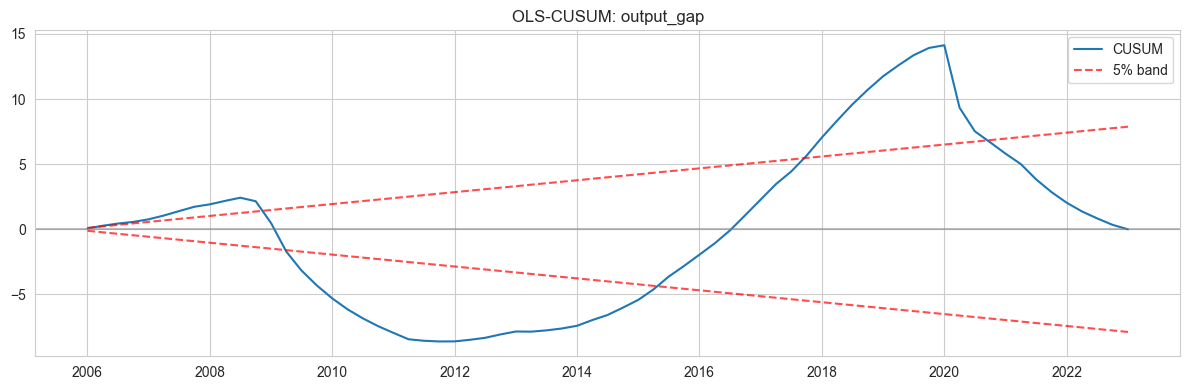

CUSUM test statistic = 1.688, p = 0.0067
  Parameter instability detected at 5%



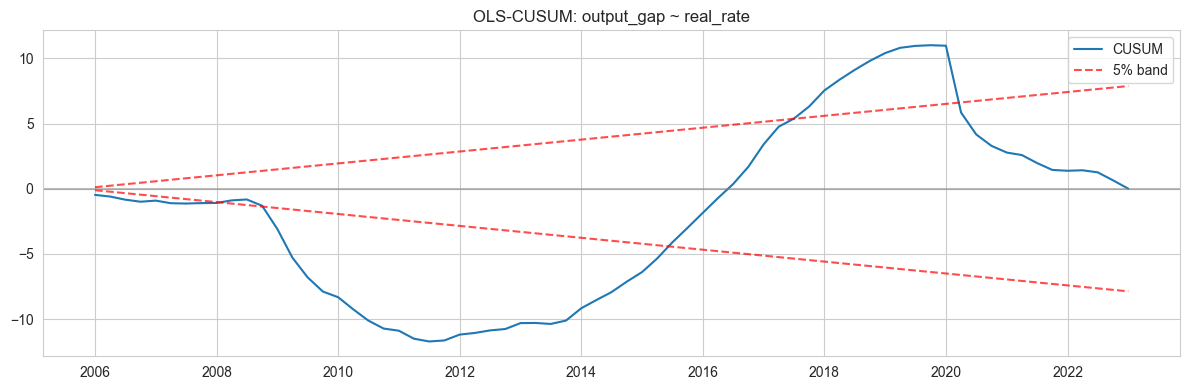

CUSUM test statistic = 1.390, p = 0.0419
  Parameter instability detected at 5%



In [36]:
def cusum_plot(y: pd.Series, x: pd.Series = None):
    """OLS-CUSUM test. If x is None, regress y on a constant (tests mean stability)."""
    if x is None:
        data = y.dropna()
        X = np.ones((len(data), 1))
        y_arr = data.values
    else:
        data = pd.concat([y, x], axis=1).dropna()
        y_arr = data.iloc[:, 0].values
        X = add_constant(data.iloc[:, 1].values)

    res = OLS(y_arr, X).fit()
    cusum_stat, p_val, crit = breaks_cusumolsresid(res.resid, ddof=X.shape[1])

    # Hand-rolled CUSUM plot of OLS residuals (scaled)
    sigma = res.resid.std()
    cumsum = np.cumsum(res.resid) / sigma
    n = len(cumsum)
    t = np.arange(1, n+1)
    # 5% bands for OLS-CUSUM (approx): ±0.948 * sqrt(n) at endpoints, linear
    band = 0.948 * np.sqrt(n) * (t / n)

    fig, ax = plt.subplots(figsize=(12, 4))
    ax.plot(data.index, cumsum, lw=1.5, label='CUSUM')
    ax.plot(data.index, band, color='red', ls='--', alpha=0.7, label='5% band')
    ax.plot(data.index, -band, color='red', ls='--', alpha=0.7)
    ax.axhline(0, color='gray', alpha=0.5)
    label = y.name if x is None else f'{y.name} ~ {x.name}'
    ax.set_title(f'OLS-CUSUM: {label}')
    ax.legend()
    plt.tight_layout()
    plt.show()

    print(f'CUSUM test statistic = {cusum_stat:.3f}, p = {p_val:.4f}')
    print(f'  {"Parameter instability detected" if p_val < 0.05 else "No instability detected"} at 5%\n')

cusum_plot(y)
if x is not None:
    cusum_plot(y, x)

## 8. Robustness — try a candidate sample

Once you've decided on a sample cutoff based on the evidence above, check that your downstream metric (correlation, regression coefficient, whatever) is stable across small perturbations of the cutoff.

In [37]:
def sample_sensitivity(y: pd.Series, x: pd.Series, candidate_start, candidate_end,
                       perturbation_periods: int = 8):
    """
    Compute correlation between y and x for the candidate sample
    and for samples shifted ±perturbation_periods on each end.
    """
    candidate_start = pd.Timestamp(candidate_start)
    candidate_end = pd.Timestamp(candidate_end)

    results = []
    for start_shift in [-perturbation_periods, 0, perturbation_periods]:
        for end_shift in [-perturbation_periods, 0, perturbation_periods]:
            start = candidate_start + pd.DateOffset(months=3*start_shift)
            end = candidate_end + pd.DateOffset(months=3*end_shift)
            sub_y = y.loc[start:end].dropna()
            sub_x = x.loc[start:end].dropna()
            common = sub_y.index.intersection(sub_x.index)
            corr = sub_y.loc[common].corr(sub_x.loc[common])
            results.append({
                'start': start.date(),
                'end': end.date(),
                'n': len(common),
                'corr': round(corr, 3)
            })

    out = pd.DataFrame(results)
    print(out.to_string(index=False))
    print(f'\nRange of correlations: [{out["corr"].min():.3f}, {out["corr"].max():.3f}]')
    if out['corr'].max() - out['corr'].min() < 0.10:
        print('Stable across perturbations — sample choice is robust.')
    else:
        print('Sensitive to cutoff — fragile result, be honest about it in writeup.')
    return out

# Edit these dates based on what stage 5-6 told you
if x is not None:
    _ = sample_sensitivity(y, x, candidate_start='2010-01-01', candidate_end='2019-12-31')

     start        end  n  corr
2008-01-01 2017-12-31 40 0.014
2008-01-01 2019-12-31 48 0.297
2008-01-01 2021-12-31 56 0.316
2010-01-01 2017-12-31 32 0.087
2010-01-01 2019-12-31 40 0.369
2010-01-01 2021-12-31 48 0.340
2012-01-01 2017-12-31 24 0.133
2012-01-01 2019-12-31 32 0.386
2012-01-01 2021-12-31 40 0.336

Range of correlations: [0.014, 0.386]
Sensitive to cutoff — fragile result, be honest about it in writeup.


## 9. Decision log

Write down your conclusion as a final cell. This forces you to articulate the reasoning.

Template:

> Based on the diagnostics:
> - Univariate Quandt-Andrews on `[series]` found a break at `[date]` (sup-F = `[value]`, significant at `[level]`).
> - Bivariate Quandt-Andrews on `[y] ~ [x]` found a break at `[date]` (sup-F = `[value]`).
> - Multi-break detection (ruptures) at penalty=3 identified breaks at: `[dates]`.
> - CUSUM `[did/did not]` detect parameter instability.
> - Rolling correlation `[was/was not]` stable across the sample.
>
> Institutional context: `[your reading of what happened on those dates]`
>
> **Decision**: restrict sample to `[start]–[end]`, on the grounds that `[reason]`.
> Sensitivity check showed the headline correlation ranges from `[min]` to `[max]` across cutoff perturbations, which is `[acceptable/concerning]`.